In [43]:
import pandas as pd
import numpy as np
import joblib

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
rf_model = joblib.load("../models/price_prediction_model.pkl")
xgb_model = joblib.load("../models/xgboost_weather.pkl")
encoders = joblib.load("../models/label_encoders.pkl")

print("✅ Models Loaded")

✅ Models Loaded


In [45]:
df = pd.read_csv("../data/final/final_dataset.csv")

print(df.shape)

df.head()

(54340, 28)


,State,Commodity_Group,Commodity,Date,Arrival,Arrival_Unit,Modal_Price,Price_Unit,District,Max_Temp,...,Day,Weekend,DayOfWeek,Quarter,Lag_1,Lag_2,Lag_3,Rolling_7,Rolling_30,Price_Change
0,Maharashtra,Vegetables,Onion,2023-01-01,4846.0,Metric Tonnes,1369.7,Rs./Quintal,Ahmednagar,28.9,...,1,False,6,1,1369.7,1369.7,1369.7,1369.7,1358.006667,0.0
1,Maharashtra,Vegetables,Onion,2023-01-01,4846.0,Metric Tonnes,1369.7,Rs./Quintal,Pune,29.9,...,1,False,6,1,1369.7,1369.7,1369.7,1369.7,1358.006667,0.0
2,Maharashtra,Vegetables,Onion,2023-01-01,4846.0,Metric Tonnes,1369.7,Rs./Quintal,Nashik,28.4,...,1,False,6,1,1369.7,1369.7,1369.7,1369.7,1358.006667,0.0
3,Maharashtra,Vegetables,Onion,2023-01-01,4846.0,Metric Tonnes,1369.7,Rs./Quintal,Solapur,31.4,...,1,False,6,1,1369.7,1369.7,1369.7,1369.7,1358.006667,0.0
4,Maharashtra,Vegetables,Onion,2023-01-01,4846.0,Metric Tonnes,1369.7,Rs./Quintal,Nagpur,27.4,...,1,False,6,1,1369.7,1369.7,1369.7,1369.7,1358.006667,0.0


In [46]:
df_test = df.copy()

# Convert Date
df_test["Date"] = pd.to_datetime(df_test["Date"])

# Encode categorical columns
categorical = [
    "State",
    "Commodity_Group",
    "Commodity",
    "District",
    "Festival"
]

for col in categorical:
    df_test[col] = encoders[col].transform(df_test[col])

print("✅ Encoding Completed")

✅ Encoding Completed


In [47]:
rf_features = list(rf_model.feature_names_in_)

X_rf = df_test[rf_features]

y = df_test["Modal_Price"]

rf_pred = rf_model.predict(X_rf)

print("✅ RF Prediction Completed")

✅ RF Prediction Completed


In [48]:
xgb_features = list(xgb_model.feature_names_in_)

X_xgb = df_test[xgb_features]

xgb_pred = xgb_model.predict(X_xgb)

print("✅ XGBoost Prediction Completed")

✅ XGBoost Prediction Completed


In [49]:
rf_mae = mean_absolute_error(y, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y, rf_pred))
rf_r2 = r2_score(y, rf_pred)

xgb_mae = mean_absolute_error(y, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y, xgb_pred))
xgb_r2 = r2_score(y, xgb_pred)

comparison = pd.DataFrame({

    "Model":[
        "Random Forest",
        "XGBoost"
    ],

    "MAE":[
        rf_mae,
        xgb_mae
    ],

    "RMSE":[
        rf_rmse,
        xgb_rmse
    ],

    "R2":[
        rf_r2,
        xgb_r2
    ]

})

comparison

,Model,MAE,RMSE,R2
0,Random Forest,2.018260,46.296814,0.998828
1,XGBoost,81.206175,120.260630,0.992094


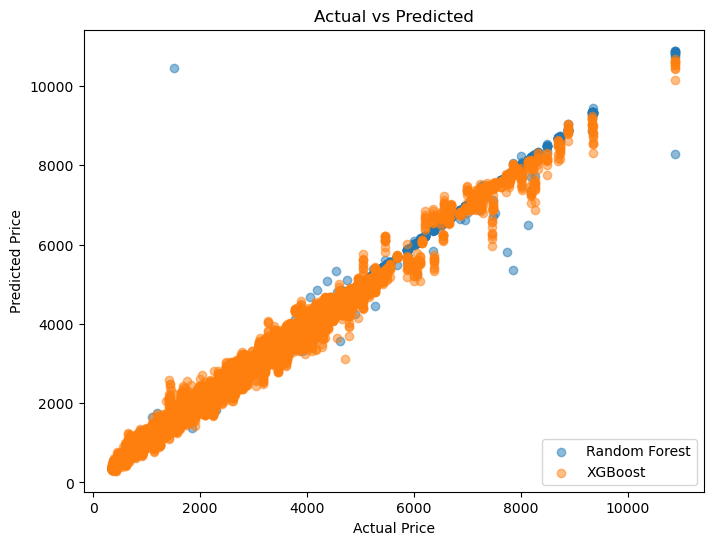

In [50]:
plt.figure(figsize=(8,6))

plt.scatter(
    y,
    rf_pred,
    alpha=.5,
    label="Random Forest"
)

plt.scatter(
    y,
    xgb_pred,
    alpha=.5,
    label="XGBoost"
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.legend()

plt.show()

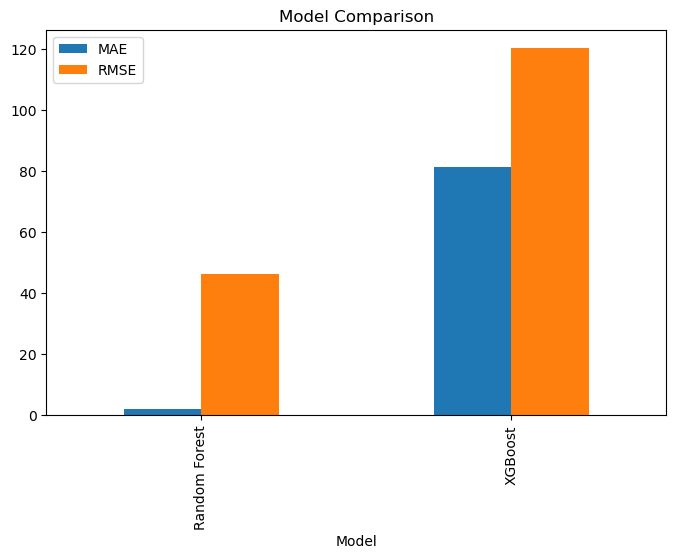

In [51]:
comparison.set_index("Model")[["MAE","RMSE"]].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Comparison")

plt.show()

In [52]:
result = df.copy()

result["RF_Prediction"] = rf_pred

result["XGB_Prediction"] = xgb_pred

result.to_csv(
    "../reports/model_predictions.csv",
    index=False
)

print("✅ Prediction File Saved")

✅ Prediction File Saved
